In [1]:
# ===============================
# IMPORTING REQUIRED LIBRARIES
# ===============================

# Regular expressions for cleaning text
import re

# NLTK for tokenization
import nltk
from nltk.tokenize import word_tokenize

# Counter to count word frequencies
from collections import Counter

# Word2Vec model from gensim
from gensim.models import Word2Vec

# PCA for dimensionality reduction
from sklearn.decomposition import PCA

# Visualization libraries
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Download tokenizer resources (only needed once)
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
# ===============================
# STEP 1: TEXT CLEANING FUNCTION
# ===============================

def structured_text_cleaner(raw_input_text):
    """
    This function prepares raw collected data for NLP processing.

    Steps performed:
    1. Remove HTML tags if present
    2. Convert text to lowercase
    3. Remove numbers and special characters
    4. Normalize spaces
    """

    # Remove HTML tags
    no_html = re.sub(r'<.*?>', ' ', raw_input_text)

    # Convert to lowercase
    lower_text = no_html.lower()

    # Replace unwanted characters with space
    alpha_only = re.sub(r'[^a-z\s]', ' ', lower_text)

    # Remove extra spaces
    clean_text = re.sub(r'\s+', ' ', alpha_only).strip()

    return clean_text

In [3]:
# ===============================
# STEP 2: TOKENIZATION
# ===============================

def token_builder(clean_ready_text):
    """
    Converts cleaned text into tokens (words).
    Tokenization helps the model understand individual units.
    """
    return word_tokenize(clean_ready_text)

In [4]:
# ===============================
# STEP 3: LOAD DATA
# ===============================

# Read the dataset file
with open("iitj_corpus_raw.txt", "r", encoding="utf-8") as data_file:
    raw_corpus_data = data_file.read()

# Apply cleaning
cleaned_corpus = structured_text_cleaner(raw_corpus_data)

# Convert into tokens
token_stream = token_builder(cleaned_corpus)

In [5]:
# ===============================
# STEP 4: DATASET STATISTICS
# ===============================

print("Total tokens:", len(token_stream))
print("Vocabulary size:", len(set(token_stream)))

# Frequency analysis
frequency_map = Counter(token_stream)
print("Top 10 words:", frequency_map.most_common(10))

Total tokens: 17519
Vocabulary size: 1918
Top 10 words: [('the', 1143), ('of', 718), ('to', 434), ('a', 426), ('for', 383), ('in', 345), ('and', 343), ('be', 275), ('student', 219), ('m', 205)]


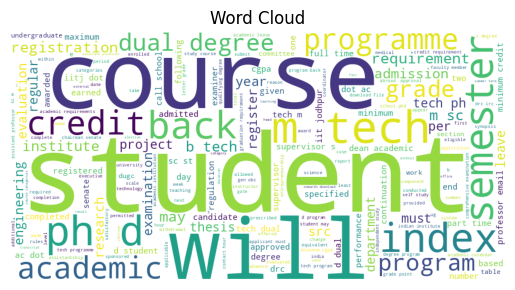

In [6]:
# ===============================
# STEP 5: WORD CLOUD
# ===============================

combined_text = " ".join(token_stream)

wc = WordCloud(width=900, height=450, background_color='white')
wc_image = wc.generate(combined_text)

plt.imshow(wc_image)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [7]:
# ===============================
# STEP 6: PREPARE SENTENCES
# ===============================

def sequence_chunker(tokens, chunk_size=20):
    """
    Break token list into smaller chunks.
    Word2Vec expects list of sentences.
    """
    return [tokens[i:i+chunk_size] for i in range(0, len(tokens), chunk_size)]

training_sequences = sequence_chunker(token_stream)

In [8]:
# ===============================
# STEP 7: TRAIN WORD2VEC MODELS
# ===============================

# CBOW Model
cbow_model = Word2Vec(
    sentences=training_sequences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=0,
    negative=5,
    epochs=10
)

# Skip-gram Model
skip_model = Word2Vec(
    sentences=training_sequences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    negative=5,
    epochs=10
)

In [9]:
# ===============================
# STEP 8: SEMANTIC ANALYSIS
# ===============================

test_words = ["research", "student", "phd", "exam"]

for word in test_words:
    if word in cbow_model.wv:
        print(f"\nNearest words for {word}:")
        print(cbow_model.wv.most_similar(word, topn=5))
    else:
        print(f"{word} not found in vocabulary")


Nearest words for research:
[('two', 0.99956876039505), ('after', 0.9995048642158508), ('with', 0.9995025992393494), ('under', 0.9995003938674927), ('committee', 0.9994964599609375)]

Nearest words for student:
[('can', 0.9991390109062195), ('who', 0.9990420341491699), ('an', 0.9990137219429016), ('from', 0.9989760518074036), ('courses', 0.9989385008811951)]

Nearest words for phd:
[('email', 0.9982982873916626), ('at', 0.9964606165885925), ('professor', 0.996399462223053), ('iitj', 0.9957653880119324), ('school', 0.995712161064148)]
exam not found in vocabulary


In [10]:
# ===============================
# STEP 9: ANALOGY TEST
# ===============================

try:
    analogy = skip_model.wv.most_similar(
        positive=["pg", "btech"],
        negative=["ug"]
    )
    print("UG : BTech :: PG : ?", analogy)
except:
    print("Analogy words missing")

Analogy words missing


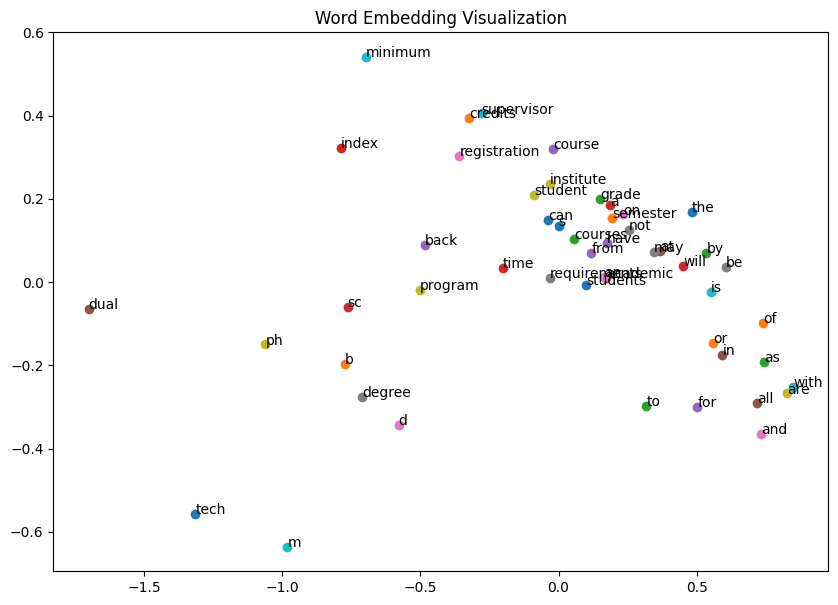

In [11]:
# ===============================
# STEP 10: PCA VISUALIZATION
# ===============================

words = list(cbow_model.wv.index_to_key)[:50]
vectors = [cbow_model.wv[w] for w in words]

pca = PCA(n_components=2)
points = pca.fit_transform(vectors)

plt.figure(figsize=(10,7))

for i, word in enumerate(words):
    plt.scatter(points[i][0], points[i][1])
    plt.text(points[i][0], points[i][1], word)

plt.title("Word Embedding Visualization")
plt.show()